In [1]:
!pip install arch

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/929.7 kB ? eta -:--:--
   ---------------------------------------- 0.0/929.7 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/929.7 kB ? eta -:--:--
   ---------------------- ----------------- 524.3/929.7 kB 1.4 MB/s eta 0:00:01
   --------------------------------- ------ 786.4/929.7 kB 1.3 MB/s eta 0:00:01
   ---------------------------------------- 929.7/929.7 kB 1.3 MB/s  0:00:00


In [2]:
# import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model
import warnings

In [3]:
warnings.filterwarnings("ignore")  # Ignore warnings for cleaner output

In [4]:
df = pd.read_csv(r'../data/processed/cleaned_featured_data.csv', parse_dates=['observation_date'], index_col='observation_date')
df

,DHHNGSP,lag_1,lag_2,lag_3,Rolling_Std_7,Stationary_Target
observation_date,,,,,,
2021-07-13,3.78,NaN,NaN,NaN,NaN,3.78
2021-07-14,3.80,3.78,NaN,NaN,NaN,3.80
2021-07-15,3.68,3.80,NaN,NaN,NaN,3.68
2021-07-16,3.70,3.68,NaN,NaN,NaN,3.70
2021-07-19,3.75,3.70,NaN,NaN,NaN,3.75
...,...,...,...,...,...,...
2026-07-07,3.13,3.29,3.26,3.10,0.076871,3.13
2026-07-08,3.13,3.13,3.33,3.13,0.097978,3.13
2026-07-09,3.17,3.13,3.34,3.04,0.099108,3.17


In [5]:
# Prepare Returns for GARCH Model
returns = 100 * df['DHHNGSP'].pct_change().dropna()  # Calculate daily returns and drop NaN values

In [6]:
# fit GARCH(1, 1) model
print("Fitting GARCH(1, 1) model...")
garch_model = arch_model(returns, vol='Garch', p=1, q=1)

garch_fit = garch_model.fit(disp='off') # disp='off' suppresses the output of the fitting process
print(garch_fit.summary())

Fitting GARCH(1, 1) model...
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                DHHNGSP   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -5018.73
Distribution:                  Normal   AIC:                           10045.5
Method:            Maximum Likelihood   BIC:                           10066.1
                                        No. Observations:                 1304
Date:                Sat, Jul 18 2026   Df Residuals:                     1303
Time:                        03:29:16   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu            -0.2197      0.659     -0.3

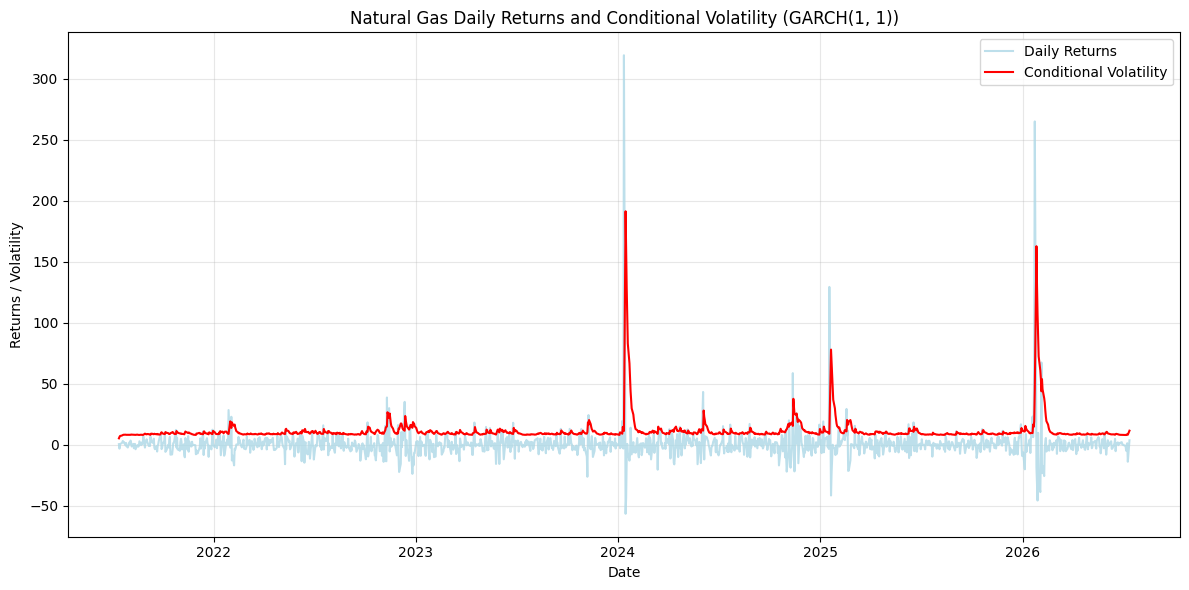

In [7]:
# Visualize volatility clusters
plt.figure(figsize=(12, 6))
plt.plot(returns.index, returns, label='Daily Returns', color='lightblue', alpha=0.8)
plt.plot(returns.index, garch_fit.conditional_volatility, label='Conditional Volatility', color='red', linewidth=1.5)
plt.title('Natural Gas Daily Returns and Conditional Volatility (GARCH(1, 1))')
plt.xlabel('Date')
plt.ylabel('Returns / Volatility')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()